# Phase 2 — Cascade Metrics

**Goal:** for each thread, compute metrics covering reach, speed, and structure. Then look at distributions by veracity to see which dimensions actually differ across rumour vs. non-rumour and within rumour types.

**Why this is the most important phase:** Phase 1 told us that on simple cascade size, **non-rumours are the largest cascades on PHEME** — the opposite of what most readers expect. The interesting question now is whether rumours and facts spread in *different shapes* even when their reach is comparable. Structural virality (Goel et al. 2016) is the key metric — it separates **broadcast** spread (one big account → many shallow replies) from **viral** spread (long peer-to-peer chains). If false rumours have lower reach but higher structural virality than non-rumours, that's a real and presentable finding.

**Outputs:**
- `data/processed/metrics.parquet` (or `.pkl`) — one row per thread with all metrics
- `data/processed/threads_with_metrics.parquet` — `threads_df` joined to metrics for convenience

---

## 1. Setup

In [1]:
#!pip install seaborn

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path('.').resolve()))
from cascade_metrics import compute_all_metrics

DATA_DIR = Path('../data/processed')

sns.set_style('whitegrid')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)

# Consistent veracity colors across the whole project — set them once here
# and reuse in Phase 4 figures so the presentation feels coherent.
VERACITY_ORDER = ['nonrumour', 'true', 'unverified', 'false']
VERACITY_COLORS = {
    'nonrumour':  '#4C72B0',  # blue
    'true':       '#55A868',  # green
    'unverified': '#DD8452',  # orange
    'false':      '#C44E52',  # red
}

## 2. Load Phase 1 outputs

In [3]:
# Load whichever format Phase 1 produced
def _load(name):
    pq, pkl = DATA_DIR / f'{name}.parquet', DATA_DIR / f'{name}.pkl'
    if pq.exists():
        return pd.read_parquet(pq)
    return pd.read_pickle(pkl)

threads_df = _load('threads')
tweets_df = _load('tweets')
edges_df = _load('edges')

print(f'threads: {len(threads_df):>6,}')
print(f'tweets:  {len(tweets_df):>6,}')
print(f'edges:   {len(edges_df):>6,}')

threads:  6,425
tweets:  104,582
edges:   95,076


## 3. Compute metrics

On full PHEME-9 (~6,400 threads) this takes ~1–3 minutes depending on machine. The expensive step is structural virality, which requires all-pairs shortest paths in each cascade tree — fine for trees with <500 nodes but slows down on the rare giant cascade.

If you need to iterate fast, set `SAMPLE = 200` for testing.

In [4]:
SAMPLE = None  # set to e.g. 200 for fast iteration; None for full run

if SAMPLE:
    threads_subset = threads_df.sample(n=SAMPLE, random_state=42)
    tweets_subset = tweets_df[tweets_df['thread_id'].isin(threads_subset['thread_id'])]
    edges_subset = edges_df[edges_df['thread_id'].isin(threads_subset['thread_id'])]
    print(f'Computing on {len(threads_subset)} threads (SAMPLE mode)')
else:
    threads_subset, tweets_subset, edges_subset = threads_df, tweets_df, edges_df
    print(f'Computing on all {len(threads_subset):,} threads')

metrics_df = compute_all_metrics(threads_subset, tweets_subset, edges_subset)
print(f'\nDone. Metrics shape: {metrics_df.shape}')
metrics_df.head()

Computing on all 6,425 threads


  ...   500/6425 threads


  ...  1000/6425 threads


  ...  1500/6425 threads


  ...  2000/6425 threads


...

  ...  5000/6425 threads


  ...  5500/6425 threads


  ...  6000/6425 threads



Done. Metrics shape: (6425, 13)


,thread_id,cascade_size,max_depth,max_breadth,unique_users,time_to_first_reply_min,time_to_half_cascade_min,reply_velocity_first_hour,tweets_with_timestamps,structural_virality,wiener_index,broadcast_ratio,branching_factor_mean
0,552783238415265792,10,5,5,7,18.116667,39.400000,4,10,2.911111,131.0,0.555556,1.800000
1,552783667052167168,8,3,5,7,6.783333,21.800000,6,8,2.214286,62.0,0.714286,2.333333
2,552783745565347840,6,1,5,6,5.616667,9.733333,4,6,1.666667,25.0,1.000000,5.000000
3,552784168849907712,14,10,3,6,1.533333,24.366667,12,14,4.494505,409.0,0.230769,1.300000
4,552784526955806720,17,5,10,13,0.683333,8.983333,14,17,3.058824,416.0,0.625000,2.285714


## 4. Join metrics back to threads_df

In [5]:
tm = threads_subset.merge(metrics_df, on='thread_id', how='left')
print(f'Joined: {tm.shape}')
print(f'Columns: {list(tm.columns)}')

Joined: (6425, 33)
Columns: ['thread_id', 'event', 'is_rumour', 'veracity', 'rumour_description', 'is_turnaround', 'source_user_id', 'source_user_screen_name', 'source_user_followers', 'source_user_verified', 'source_created_at', 'source_text', 'source_retweet_count', 'source_favorite_count', 'n_reactions', 'n_edges', 'n_tweets_in_structure', 'n_skipped_malformed_nodes', 'n_self_replies_dropped', 'tweets_we_have', 'structure_completeness', 'cascade_size', 'max_depth', 'max_breadth', 'unique_users', 'time_to_first_reply_min', 'time_to_half_cascade_min', 'reply_velocity_first_hour', 'tweets_with_timestamps', 'structural_virality', 'wiener_index', 'broadcast_ratio', 'branching_factor_mean']


## 4b. Event filtering

Drop events with insufficient data for per-veracity analysis:
- **Low diversity**: fewer than 2 veracity groups with ≥30 threads (can't compare veracity classes)
- **Trivial cascades**: median cascade_size ≤ 1 (no reply activity — structural metrics are undefined for most threads)

Events passing both filters are the retained analysis set for all downstream sections.

In [6]:
MIN_N_PER_VERACITY = 30
MIN_VERACITY_GROUPS = 2

vc = tm.groupby(['event', 'veracity']).size().unstack(fill_value=0)
eligible_per_event = (vc >= MIN_N_PER_VERACITY).sum(axis=1)

low_diversity = eligible_per_event[eligible_per_event < MIN_VERACITY_GROUPS].index.tolist()

event_median_cascade = tm.groupby('event')['cascade_size'].median()
trivial_cascade = event_median_cascade[event_median_cascade <= 1].index.tolist()

EVENTS_DROP = sorted(set(low_diversity + trivial_cascade))
EVENTS_KEEP = sorted(set(tm['event'].unique()) - set(EVENTS_DROP))

print('Thread counts per event × veracity:')
print(vc.to_string())
print(f'\nEligible veracity groups (≥{MIN_N_PER_VERACITY} threads) per event:')
print(eligible_per_event.sort_values(ascending=False).to_string())
print(f'\nMedian cascade_size per event:')
print(event_median_cascade.sort_values(ascending=False).round(2).to_string())
print(f'\nDropped — low veracity diversity (<{MIN_VERACITY_GROUPS} groups): {low_diversity}')
print(f'Dropped — trivial cascades (median size ≤ 1):                {trivial_cascade}')
print(f'\nKeeping ({len(EVENTS_KEEP)}): {EVENTS_KEEP}')

tm = tm[tm['event'].isin(EVENTS_KEEP)].copy()
threads_subset = threads_subset[threads_subset['event'].isin(EVENTS_KEEP)].copy()
print(f'\nFiltered dataset: {len(tm):,} threads across {tm["event"].nunique()} events')

Thread counts per event × veracity:
veracity           false  nonrumour  true  unverified
event                                                
charliehebdo         116       1621   193         149
ebola-essien          14          0     0           0
ferguson               8        859    10         266
germanwings-crash    111        230    94          34
gurlitt                0         77    59           2
ottawashooting        72        420   329          69
prince-toronto       222          4     0           7
putinmissing           9        112     0         117
sydneysiege           86        699   382          54

Eligible veracity groups (≥30 threads) per event:
event
charliehebdo         4
germanwings-crash    4
ottawashooting       4
sydneysiege          4
ferguson             2
gurlitt              2
putinmissing         2
prince-toronto       1
ebola-essien         0

Median cascade_size per event:
event
sydneysiege          17.0
ebola-essien         15.5
charliehebdo    

## 5. Per-event medians by veracity

For each metric, a table of median values broken down by event × veracity. NaN means that event had too few threads in that category. This is the primary summary — pooled medians are intentionally omitted because events vary enormously in size and topic.

In [7]:
metric_cols = [
    'cascade_size', 'max_depth', 'max_breadth', 'unique_users',
    'time_to_first_reply_min', 'time_to_half_cascade_min', 'reply_velocity_first_hour',
    'structural_virality', 'wiener_index', 'broadcast_ratio', 'branching_factor_mean',
]

print('=== Median by event × veracity ===\n')
for metric in metric_cols:
    pivot = (
        tm.groupby(['event', 'veracity'])[metric]
        .median()
        .unstack('veracity')
        .reindex(columns=[v for v in VERACITY_ORDER if v in tm['veracity'].unique()])
        .round(2)
    )
    print(f'--- {metric} ---')
    print(pivot.to_string())
    print()

=== Median by event × veracity ===

--- cascade_size ---
veracity           nonrumour  true  unverified  false
event                                                
charliehebdo            16.0  12.0        13.0    9.5
ferguson                14.0  17.0        16.5   12.5
germanwings-crash        5.5   5.0         9.5    5.0
ottawashooting          11.0  12.0        11.0    9.0
putinmissing             2.0   NaN         2.0    1.0
sydneysiege             18.0  15.0        13.5   18.0

--- max_depth ---
veracity           nonrumour  true  unverified  false
event                                                
charliehebdo             2.0   2.0         2.0    2.0
ferguson                 2.0   3.0         3.0    4.5
germanwings-crash        1.0   1.0         2.0    1.0
ottawashooting           2.0   2.0         2.0    2.0
putinmissing             1.0   NaN         1.0    0.0
sydneysiege              3.0   2.0         2.0    3.0

--- max_breadth ---
veracity           nonrumour  true  unv

**How to read these tables.** Each row is an event; columns are veracity classes. Compare across columns *within each row* to see the pattern for that event. A finding is robust only if the same direction holds in most events. NaN = too few threads in that (event, veracity) to show a stable median.

## 6. Per-event distribution panels

One panel per retained event, colored by veracity. This replaces a single pooled boxplot — pooling across events with different baseline sizes would inflate apparent differences.

/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

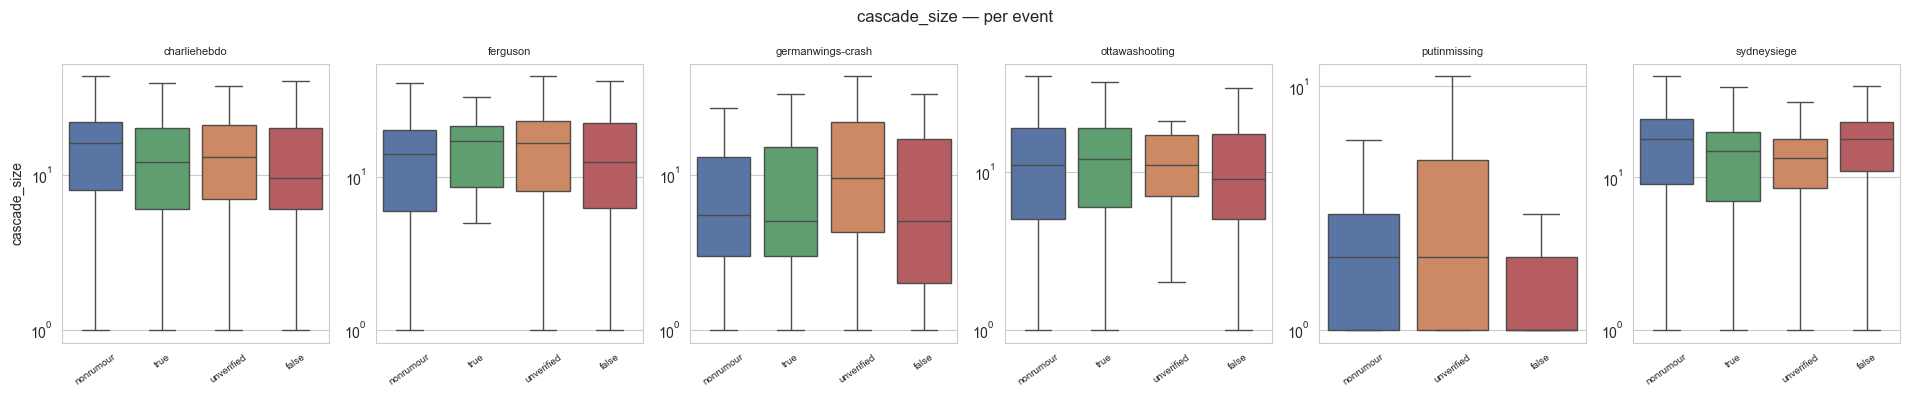

/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

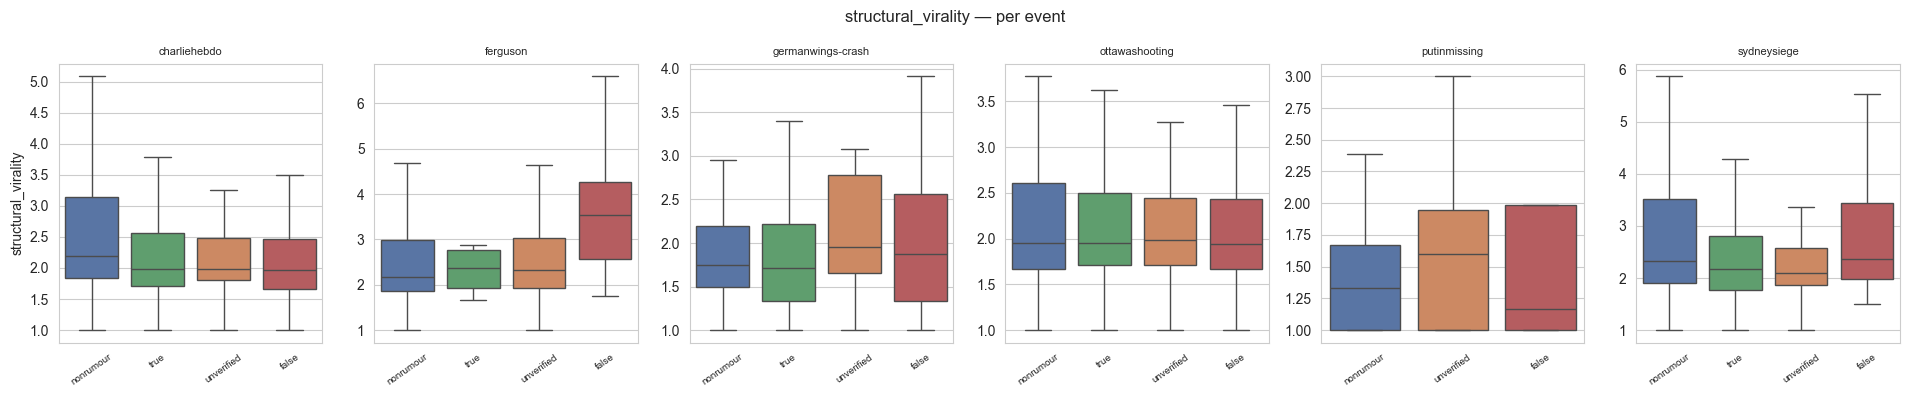

/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

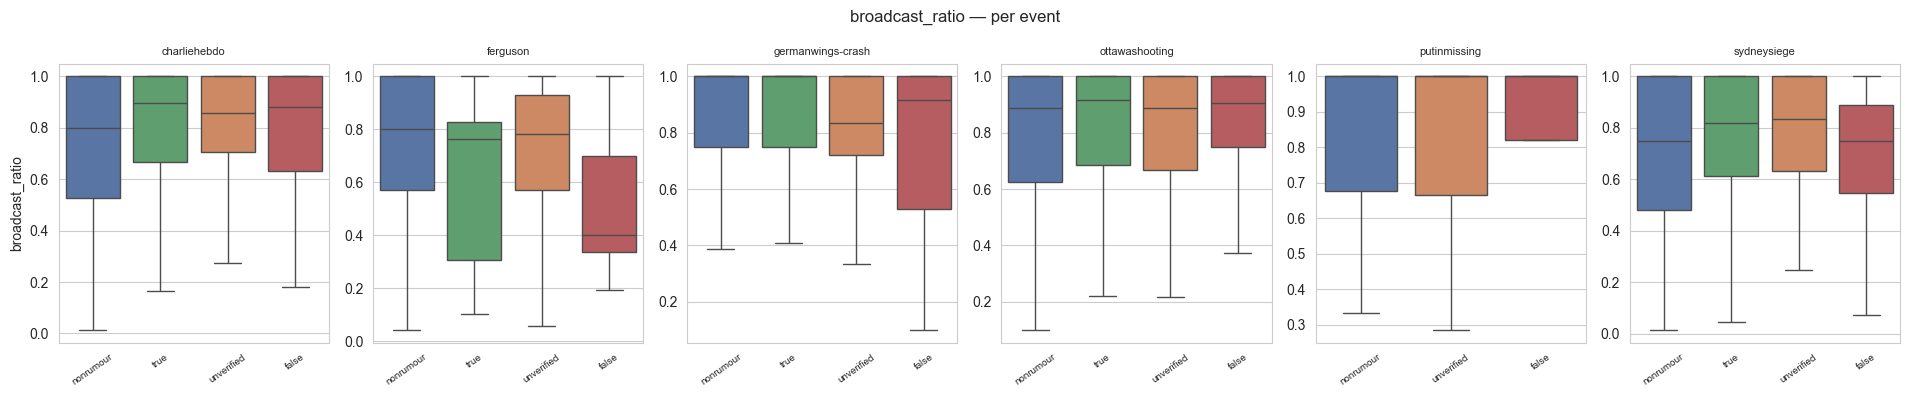

/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

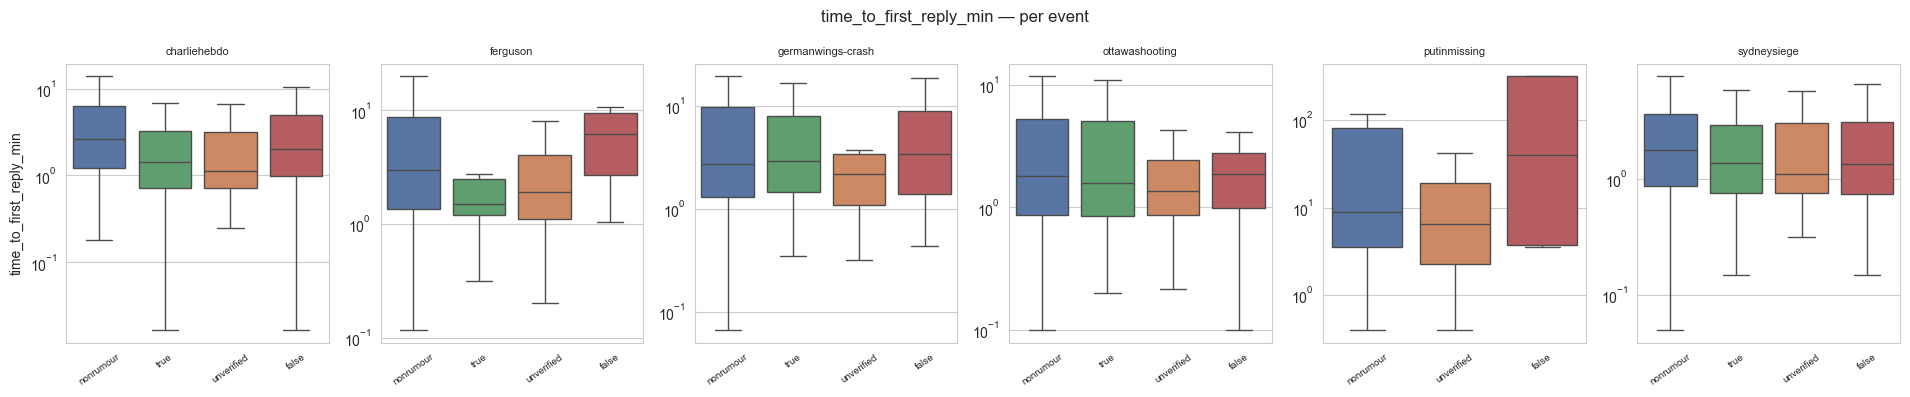

/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/3772787497.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

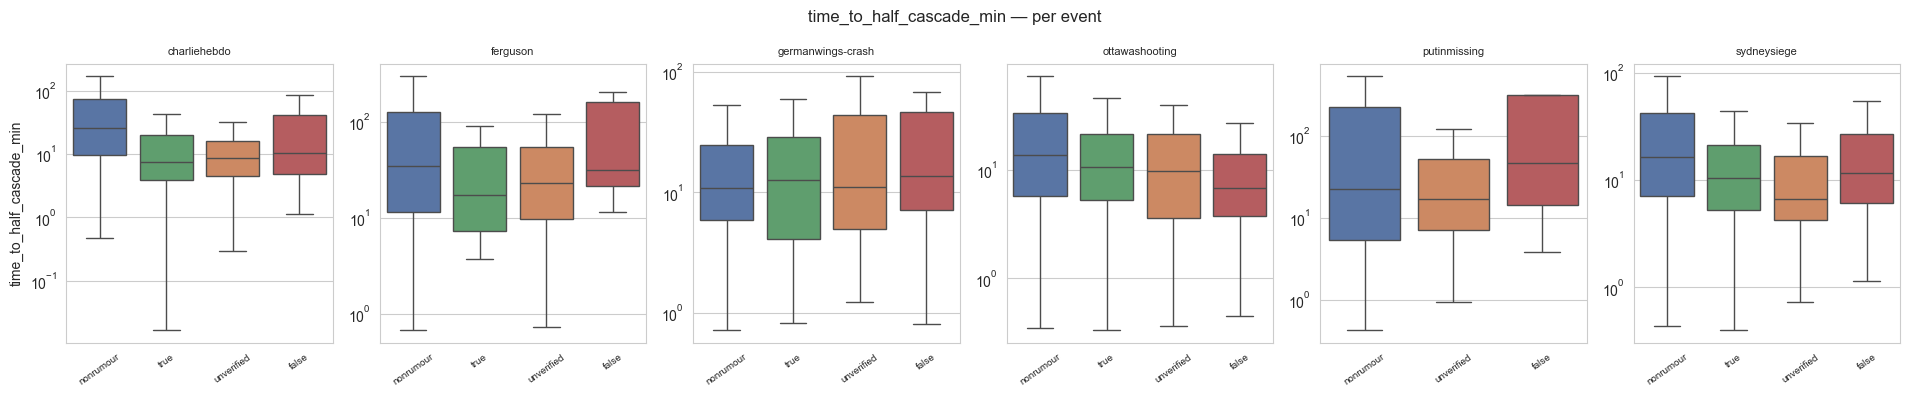

In [8]:
key_metrics_plot = [
    'cascade_size', 'structural_virality', 'broadcast_ratio',
    'time_to_first_reply_min', 'time_to_half_cascade_min',
]
log_metrics_plot = {'cascade_size', 'time_to_first_reply_min', 'time_to_half_cascade_min'}
events_sorted = sorted(tm['event'].unique())
n_events = len(events_sorted)

for metric in key_metrics_plot:
    fig, axes = plt.subplots(1, n_events, figsize=(3.2 * n_events, 4), sharey=False)
    if n_events == 1:
        axes = [axes]
    for ax, event in zip(axes, events_sorted):
        ev_data = tm[(tm['event'] == event) & tm[metric].notna()]
        if metric in log_metrics_plot:
            ev_data = ev_data[ev_data[metric] > 0]
        present = [v for v in VERACITY_ORDER if v in ev_data['veracity'].values]
        if not present:
            ax.axis('off')
            continue
        sns.boxplot(
            data=ev_data, x='veracity', y=metric,
            order=present,
            palette={v: VERACITY_COLORS[v] for v in present},
            showfliers=False, ax=ax,
        )
        if metric in log_metrics_plot:
            ax.set_yscale('log')
        ax.set_title(event, fontsize=8)
        ax.set_xlabel('')
        ax.tick_params(axis='x', labelsize=7, rotation=35)
        if ax != axes[0]:
            ax.set_ylabel('')
    fig.suptitle(f'{metric} — per event', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'../rumors/figures/phase2_{metric}_per_event.png', dpi=120, bbox_inches='tight')
    plt.show()

## 7. Per-event summary heatmap — all metrics

Compact view of all metrics across retained events. Each cell shows the median for that (event × veracity) combination. Colors are row-normalized: green = highest in that row, red = lowest. Useful for spotting which metrics and which events drive the overall pattern.

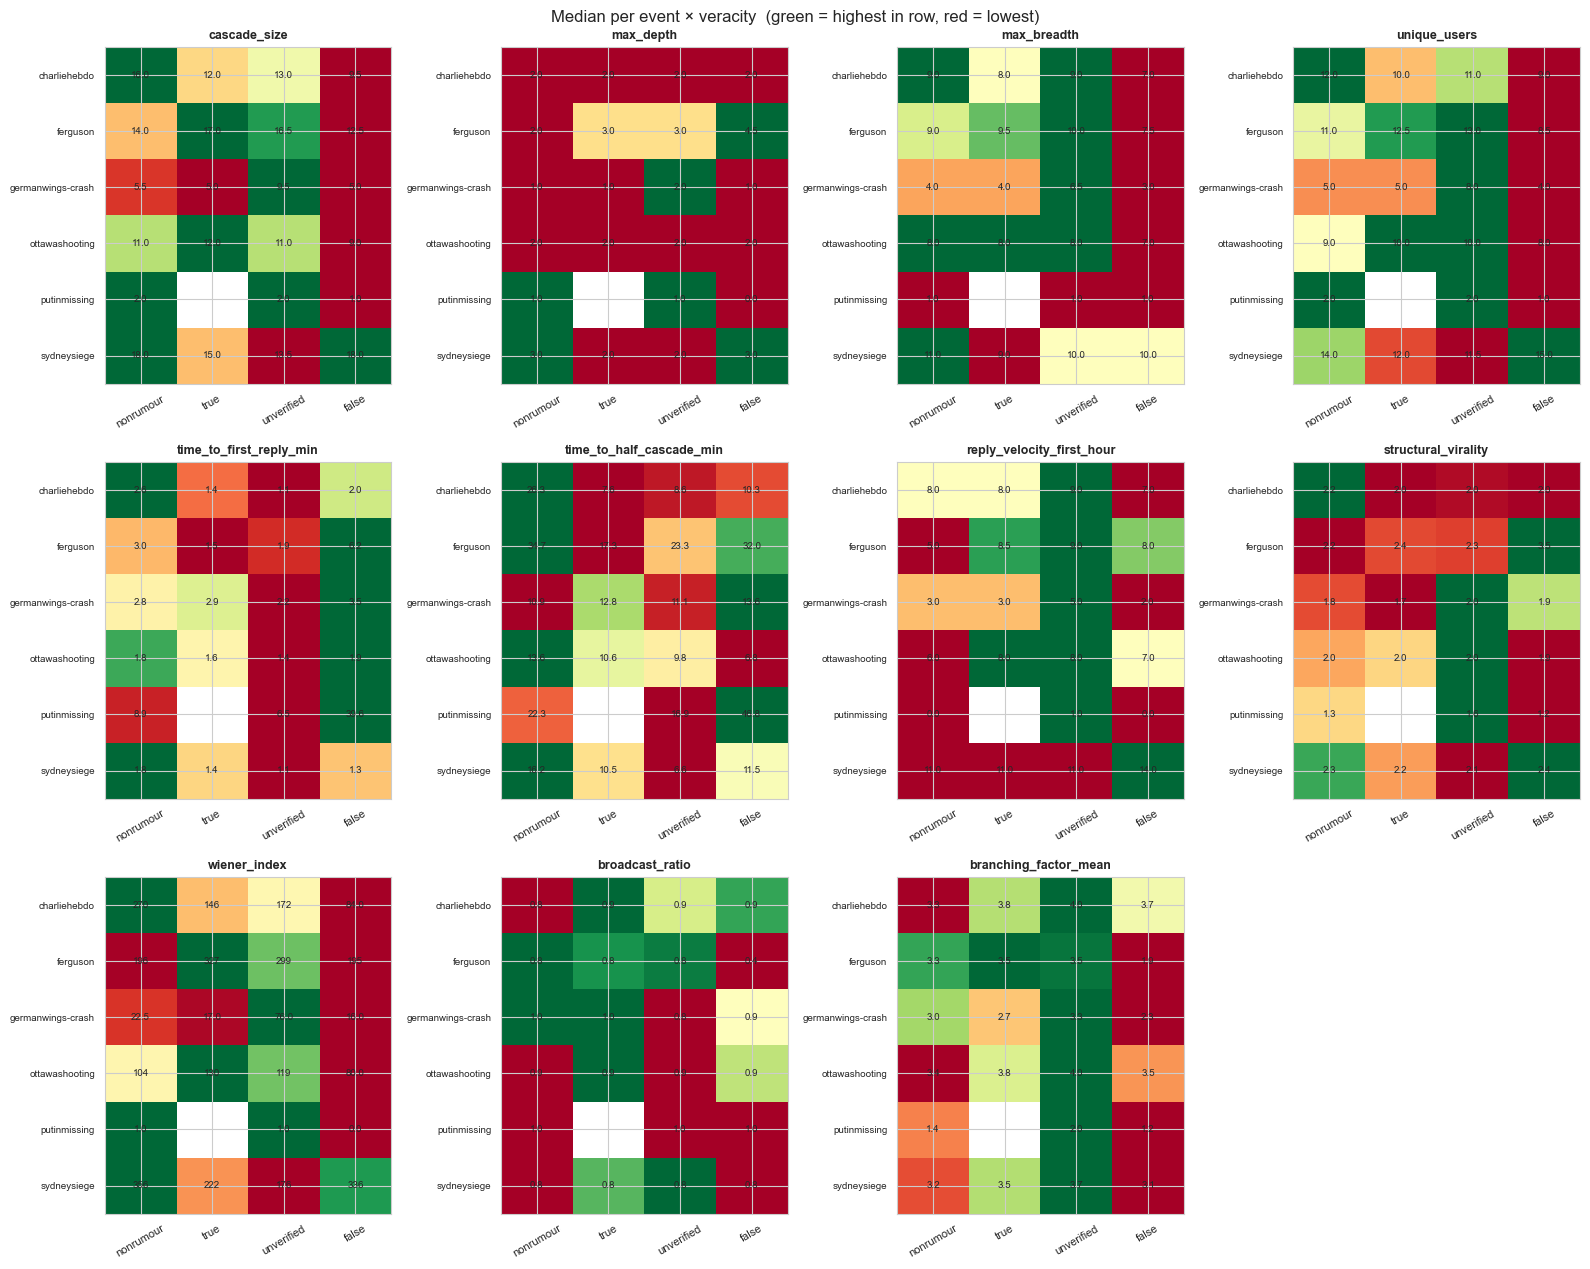

In [9]:
events_sorted = sorted(tm['event'].unique())
veracities_present = [v for v in VERACITY_ORDER if v in tm['veracity'].unique()]
n_metrics = len(metric_cols)
n_cols_fig = 4
n_rows_fig = (n_metrics + n_cols_fig - 1) // n_cols_fig

fig, axes = plt.subplots(
    n_rows_fig, n_cols_fig,
    figsize=(n_cols_fig * 4, n_rows_fig * max(3, 0.55 * len(events_sorted) + 1))
)
axes = axes.flatten()

for ax_idx, metric in enumerate(metric_cols):
    ax = axes[ax_idx]
    pivot = (
        tm.groupby(['event', 'veracity'])[metric]
        .median()
        .unstack('veracity')
        .reindex(index=events_sorted, columns=veracities_present)
    )
    row_min = pivot.min(axis=1, skipna=True)
    row_max = pivot.max(axis=1, skipna=True)
    norm_vals = pivot.subtract(row_min, axis=0).divide((row_max - row_min).replace(0, 1), axis=0)
    masked = np.ma.masked_invalid(norm_vals.values.astype(float))
    ax.imshow(masked, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(len(veracities_present)))
    ax.set_xticklabels(veracities_present, fontsize=8, rotation=30)
    ax.set_yticks(range(len(events_sorted)))
    ax.set_yticklabels(events_sorted, fontsize=7)
    ax.set_title(metric, fontsize=9, fontweight='bold')
    for i, ev in enumerate(events_sorted):
        for j, ver in enumerate(veracities_present):
            val = pivot.loc[ev, ver] if (ev in pivot.index and ver in pivot.columns) else float('nan')
            if pd.notna(val):
                txt = f'{val:.0f}' if abs(val) >= 100 else f'{val:.1f}'
                ax.text(j, i, txt, ha='center', va='center', fontsize=7)

for ax in axes[n_metrics:]:
    ax.axis('off')

plt.suptitle(
    'Median per event × veracity  (green = highest in row, red = lowest)',
    fontsize=12
)
plt.tight_layout()
plt.savefig('../rumors/figures/phase2_per_event_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Follower analysis

`source_user_followers` is the follower count of the account that posted the original rumour/non-rumour tweet. This matters because large accounts (news orgs, verified journalists) predominantly post non-rumours and attract many direct replies — a broadcast pattern. If followers strongly predict cascade size but not structural virality, then content type — not account size — is driving structural differences.

Three views:
1. **Follower distributions by veracity** (per event) — do rumour types systematically differ in account size?
2. **Median followers table** — compact reference.
3. **Spearman ρ: followers vs each cascade metric** — which cascade properties are follower-driven vs content-driven?
4. **Scatter: followers vs cascade size** (log-log) — visualize the relationship.

/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/479978726.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/479978726.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/479978726.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8g/09vpxhc96pxg6l746w68d4d40000gn/T/ipykernel_10115/479978726.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

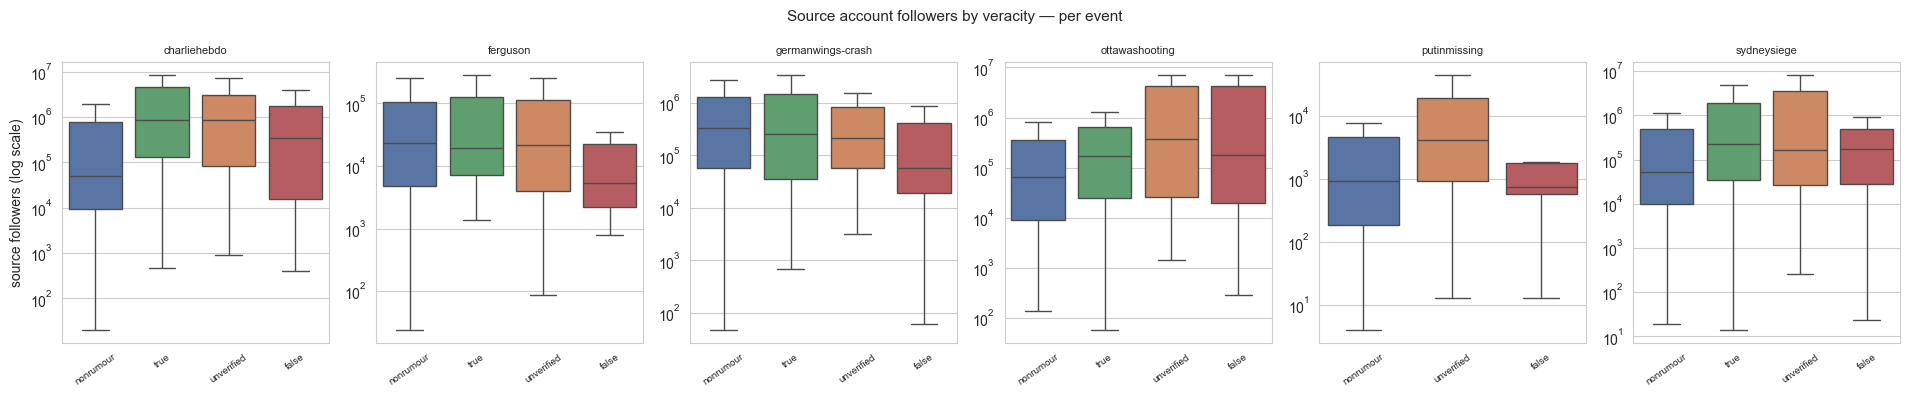

In [10]:
events_fol = sorted(tm['event'].unique())
fig, axes = plt.subplots(1, len(events_fol), figsize=(3.2 * len(events_fol), 4), sharey=False)
if len(events_fol) == 1:
    axes = [axes]

for ax, event in zip(axes, events_fol):
    data = tm[
        (tm['event'] == event) &
        tm['source_user_followers'].notna() &
        (tm['source_user_followers'] > 0)
    ]
    present = [v for v in VERACITY_ORDER if v in data['veracity'].values]
    sns.boxplot(
        data=data, x='veracity', y='source_user_followers',
        order=present,
        palette={v: VERACITY_COLORS[v] for v in present},
        showfliers=False, ax=ax,
    )
    ax.set_yscale('log')
    ax.set_title(event, fontsize=8)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=7, rotation=35)
    if ax != axes[0]:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('source followers (log scale)')

fig.suptitle('Source account followers by veracity — per event', fontsize=11)
plt.tight_layout()
plt.savefig('../rumors/figures/phase2_followers_by_veracity.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
follower_pivot = (
    tm.groupby(['event', 'veracity'])['source_user_followers']
    .median()
    .unstack('veracity')
    .reindex(columns=[v for v in VERACITY_ORDER if v in tm['veracity'].unique()])
    .round(0)
)
print('=== Median source_user_followers by event × veracity ===')
print(follower_pivot.to_string())
print()
print('=== Thread counts per event × veracity ===')
print(
    tm.groupby(['event', 'veracity']).size()
    .unstack('veracity', fill_value=0)
    .reindex(columns=[v for v in VERACITY_ORDER if v in tm['veracity'].unique()])
    .to_string()
)

=== Median source_user_followers by event × veracity ===
veracity           nonrumour      true  unverified     false
event                                                       
charliehebdo         50446.0  852151.0    843487.0  346279.0
ferguson             23689.0   19564.0     21401.0    5429.0
germanwings-crash   327154.0  260518.0    213604.0   58408.0
ottawashooting       65746.0  173317.0    381272.0  181332.0
putinmissing           912.0       NaN      4150.0     748.0
sydneysiege          53760.0  225451.0    162384.0  170858.0

=== Thread counts per event × veracity ===
veracity           nonrumour  true  unverified  false
event                                                
charliehebdo            1621   193         149    116
ferguson                 859    10         266      8
germanwings-crash        230    94          34    111
ottawashooting           420   329          69     72
putinmissing             112     0         117      9
sydneysiege              699   38

=== Spearman ρ: source_user_followers vs cascade metrics (per event) ===
(only events with ≥30 valid rows; positive = more followers → higher metric)

event                      charliehebdo  ferguson  germanwings-crash  ottawashooting  putinmissing  sydneysiege
metric                                                                                                         
branching_factor_mean             0.213     0.321              0.339           0.153         0.303        0.150
broadcast_ratio                   0.093     0.148              0.067          -0.125         0.001        0.103
cascade_size                      0.120     0.137              0.196           0.288         0.350        0.058
max_breadth                       0.233     0.242              0.284           0.297         0.350        0.165
max_depth                        -0.050    -0.060             -0.015           0.162         0.064       -0.062
reply_velocity_first_hour         0.298     0.287              0.

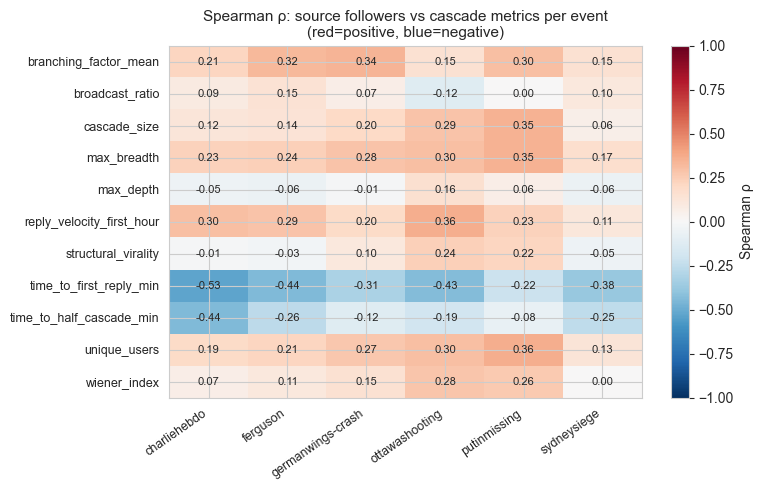

In [12]:
from scipy.stats import spearmanr

corr_rows = []
for event in sorted(tm['event'].unique()):
    ev = tm[tm['event'] == event]
    mask_fol = ev['source_user_followers'].notna() & (ev['source_user_followers'] > 0)
    for metric in metric_cols:
        mask = mask_fol & ev[metric].notna() & (ev[metric] > 0)
        if mask.sum() < 30:
            continue
        r, p = spearmanr(ev.loc[mask, 'source_user_followers'], ev.loc[mask, metric])
        corr_rows.append({'event': event, 'metric': metric, 'spearman_r': round(r, 3), 'p': round(p, 4)})

corr_df = pd.DataFrame(corr_rows)
corr_pivot = corr_df.pivot(index='metric', columns='event', values='spearman_r')

print('=== Spearman ρ: source_user_followers vs cascade metrics (per event) ===')
print('(only events with ≥30 valid rows; positive = more followers → higher metric)')
print()
print(corr_pivot.round(3).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(max(5, len(corr_pivot.columns) * 1.3), 5))
masked_corr = np.ma.masked_invalid(corr_pivot.values.astype(float))
im = ax.imshow(masked_corr, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Spearman ρ')
ax.set_xticks(range(len(corr_pivot.columns)))
ax.set_xticklabels(corr_pivot.columns, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(corr_pivot.index)))
ax.set_yticklabels(corr_pivot.index, fontsize=9)
for i in range(len(corr_pivot.index)):
    for j in range(len(corr_pivot.columns)):
        val = corr_pivot.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Spearman ρ: source followers vs cascade metrics per event\n(red=positive, blue=negative)', fontsize=11)
plt.tight_layout()
plt.savefig('../rumors/figures/phase2_followers_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

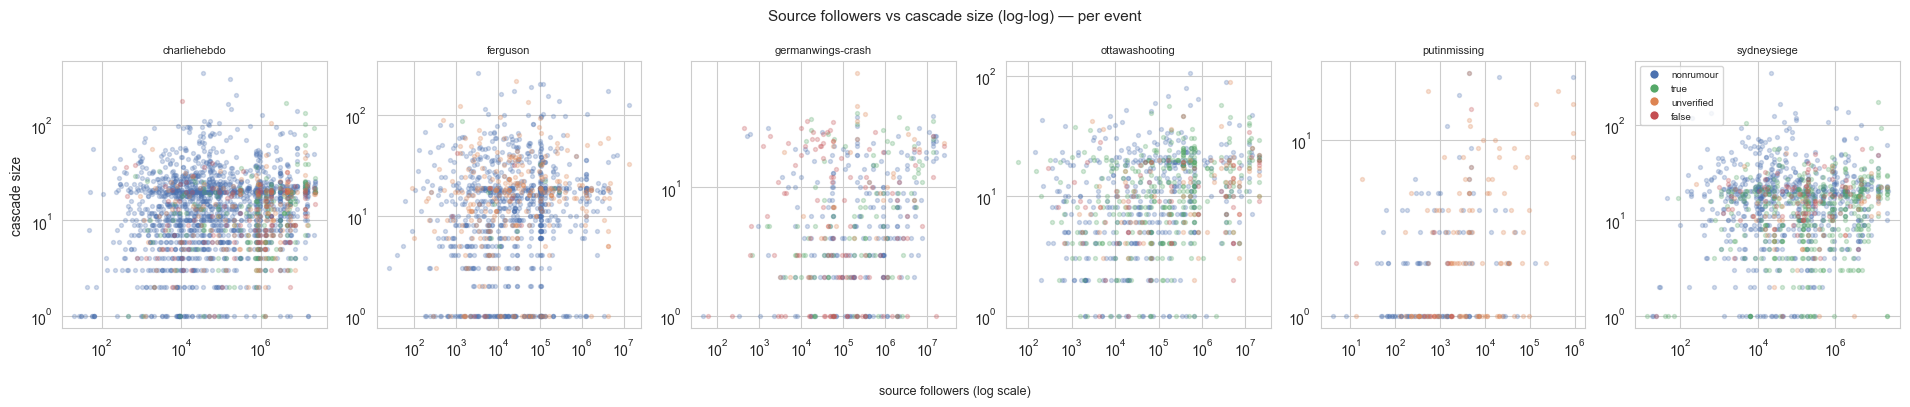

In [13]:
# Scatter: log(followers) vs cascade_size per event, colored by veracity
events_sorted_fol = sorted(tm['event'].unique())
fig, axes = plt.subplots(1, len(events_sorted_fol), figsize=(3.2 * len(events_sorted_fol), 4))
if len(events_sorted_fol) == 1:
    axes = [axes]

for ax, event in zip(axes, events_sorted_fol):
    data = tm[
        (tm['event'] == event) &
        tm['source_user_followers'].notna() &
        tm['cascade_size'].notna() &
        (tm['source_user_followers'] > 0) &
        (tm['cascade_size'] > 0)
    ]
    for v in VERACITY_ORDER:
        sub = data[data['veracity'] == v]
        if len(sub) == 0:
            continue
        ax.scatter(sub['source_user_followers'], sub['cascade_size'],
                   c=VERACITY_COLORS[v], alpha=0.25, s=8, label=v, rasterized=True)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(event, fontsize=8)
    ax.set_xlabel('')
    if ax != axes[0]:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('cascade size')

handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=VERACITY_COLORS[v], markersize=7, label=v)
    for v in VERACITY_ORDER
]
axes[-1].legend(handles=handles, fontsize=7, loc='upper left')
fig.supxlabel('source followers (log scale)', fontsize=9)
fig.suptitle('Source followers vs cascade size (log-log) — per event', fontsize=11)
plt.tight_layout()
plt.savefig('../rumors/figures/phase2_followers_vs_cascade_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Save outputs

These feed directly into Phase 3 (statistical tests + within-event comparisons).

In [14]:
try:
    metrics_df.to_parquet(DATA_DIR / 'metrics.parquet', index=False)
    tm.to_parquet(DATA_DIR / 'threads_with_metrics.parquet', index=False)
    ext = 'parquet'
except ImportError:
    metrics_df.to_pickle(DATA_DIR / 'metrics.pkl')
    tm.to_pickle(DATA_DIR / 'threads_with_metrics.pkl')
    ext = 'pkl'

print(f'Saved as .{ext}:')
for p in sorted(DATA_DIR.glob(f'*.{ext}')):
    print(f'  {p.name}  ({p.stat().st_size/1024:.1f} KB)')

Saved as .parquet:
  edges.parquet  (1966.4 KB)
  medians_with_ci.parquet  (8.0 KB)
  metrics.parquet  (226.9 KB)
  stats_consistency.parquet  (7.9 KB)
  stats_per_event.parquet  (16.7 KB)
  stats_pooled.parquet  (8.0 KB)
  threads.parquet  (755.4 KB)
  threads_with_metrics.parquet  (844.5 KB)
  threads_with_verifiability.parquet  (900.2 KB)
  tweets.parquet  (12027.5 KB)


In [15]:
ferg = tweets_df[tweets_df['thread_id'].isin(
    threads_df[threads_df['event']=='ferguson']['thread_id']
)]
print("Unique ferguson timestamp seconds (first 20):")
print(ferg['created_at'].dt.second.value_counts().head(20))
print()
print("Time deltas in ferguson (raw, first 20):")
ferg_threads = threads_df[threads_df['event']=='ferguson'].head(5)
for _, t in ferg_threads.iterrows():
    src_time = t['source_created_at']
    replies = ferg[(ferg['thread_id']==t['thread_id']) & (~ferg['is_source'])]
    if len(replies):
        print(f"  thread {t['thread_id']}: src={src_time}, first reply={replies['created_at'].min()}")

Unique ferguson timestamp seconds (first 20):
created_at
57    452
34    439
10    425
44    417
26    415
54    415
49    413
2     413
41    410
30    409
33    407
46    406
47    406
12    405
20    400
0     400
13    399
7     399
40    399
1     399
Name: count, dtype: int64

Time deltas in ferguson (raw, first 20):
  thread 498254340310966273: src=2014-08-09 23:47:46+00:00, first reply=2014-08-10 00:13:30+00:00
  thread 498254929942028288: src=2014-08-09 23:50:07+00:00, first reply=2014-08-10 00:03:30+00:00
  thread 498272309535191041: src=2014-08-10 00:59:10+00:00, first reply=2014-08-10 01:03:56+00:00
  thread 498280126254428160: src=2014-08-10 01:30:14+00:00, first reply=2014-08-10 01:33:23+00:00
  thread 498293668655423488: src=2014-08-10 02:24:03+00:00, first reply=2014-08-10 02:24:25+00:00


In [16]:
for event in threads_df['event'].unique():
    event_threads = threads_df[threads_df['event']==event].head(20)
    n_self_replies = 0
    n_total_with_replies = 0
    for _, t in event_threads.iterrows():
        replies = tweets_df[
            (tweets_df['thread_id']==t['thread_id']) & 
            (~tweets_df['is_source'])
        ].sort_values('created_at')
        if len(replies) == 0:
            continue
        n_total_with_replies += 1
        first_reply_id = replies.iloc[0]['tweet_id']
        if first_reply_id == t['thread_id']:
            n_self_replies += 1
    print(f'{event:25s} {n_self_replies}/{n_total_with_replies} threads have source duplicated in reactions/')

charliehebdo              0/20 threads have source duplicated in reactions/
ebola-essien              0/14 threads have source duplicated in reactions/
ferguson                  0/17 threads have source duplicated in reactions/
germanwings-crash         0/20 threads have source duplicated in reactions/
gurlitt                   0/4 threads have source duplicated in reactions/
ottawashooting            0/20 threads have source duplicated in reactions/
prince-toronto            0/14 threads have source duplicated in reactions/


putinmissing              0/16 threads have source duplicated in reactions/


sydneysiege               0/20 threads have source duplicated in reactions/


---

## What to check before moving to Phase 3

Look at the heatmap in section 7 and the per-event tables in section 5.

1. **Which veracity is consistently highest/lowest across events?** A pattern in ≥4 retained events is worth testing statistically in Phase 3.
2. **Does follower count explain cascade-size differences?** Section 8 shows Spearman correlations between source followers and each cascade metric. If followers correlate strongly with cascade_size but weakly with structural_virality, then content type — not account size — drives structural differences.
3. **Any event-specific anomaly?** If a metric looks interesting in the heatmap but only 1-2 events show the pattern, it may be event-specific rather than a general finding.

Phase 3 turns whichever patterns survive this check into proper statistical tests with effect sizes and consistency scores.